# osmFISH_SS

In [1]:
import warnings
warnings.filterwarnings("ignore")
import MENDER
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.metrics import *
import time

In [2]:
## load the data using pysodb, please install pysodb in advance [https://pysodb.readthedocs.io/en/latest/]
import pysodb
sodb = pysodb.SODB()
adata_raw = sodb.load_experiment('codeluppi2018spatial','cortex')

# remove invalid cells
adata_raw = adata_raw[adata_raw.obs['Region']!='Excluded']



load experiment[cortex] in dataset[codeluppi2018spatial]


In [3]:
adata_raw

View of AnnData object with n_obs × n_vars = 4839 × 33
    obs: 'ClusterName', 'ClusterID', 'Region', 'leiden'
    uns: 'ClusterName_colors', 'Region_colors', 'leiden', 'leiden_colors', 'log1p', 'moranI', 'neighbors', 'pca', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

In [4]:

gt_obs = 'Region'

In [9]:
# input parameters of MENDER
scale = 6

# radius is set to 150 not 15, because the unit of the spatial coordination is 0.1 um for this data, as suggested by estimate_radius
radius = 150

n_domains = len(adata_raw.obs['Region'].cat.categories)

# record running time 
time_st = time.time()


adata = adata_raw.copy()



######### determine cell state using standard Leiden [start]  #########
# this step can be optionally skipped if reliable cell type annotation is available
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=4000)
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)

sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata,resolution=2,key_added='ct',random_state=666)
adata.obs['ct'] = adata.obs['ct'].astype('category')
######### determine cell state using standard Leiden [end]  #########


# main body of MENDER
msm = MENDER.MENDER_single(
    adata,
    # determine which cell state to use
    # we use the cell state got by Leiden
    ct_obs='ct',
    
    random_seed=666
)


# set the MENDER parameters


msm.set_MENDER_para(
    # default of n_scales is 6
    n_scales=scale, 
    
    # for single cell data, nn_mode is set to 'radius' 
    nn_mode='radius',
    
    # default of n_scales is 15 um (see the manuscript for why).
    # MENDER also provide a function 'estimate_radius' for estimating the radius
    nn_para=radius, 

)
# construct the context representation
msm.run_representation(
    # the number of processings
)

# set the spatial clustering parameter
# positive values for the expected number of domains
# negative values for the clustering resolution
msm.run_clustering_normal(n_domains)

time_ed = time.time()
time_cost = time_ed-time_st




scale 0, median #cells per radius (r=150): 1.0
scale 1, median #cells per radius (r=150): 2.0
scale 2, median #cells per radius (r=150): 3.0
scale 3, median #cells per radius (r=150): 4.0
scale 4, median #cells per radius (r=150): 5.0
scale 5, median #cells per radius (r=150): 6.0
searching resolution to k=11
Res =  0.1 Num of clusters =  4
Res =  0.15000000000000002 Num of clusters =  6
Res changed to 0.15000000000000002
Res =  0.2 Num of clusters =  7
Res changed to 0.2
Res =  0.25 Num of clusters =  8
Res changed to 0.25
Res =  0.3 Num of clusters =  8
Res changed to 0.3
Res =  0.35 Num of clusters =  8
Res changed to 0.35
Res =  0.39999999999999997 Num of clusters =  10
Res changed to 0.39999999999999997
Res =  0.44999999999999996 Num of clusters =  10
Res changed to 0.44999999999999996
Res =  0.49999999999999994 Num of clusters =  10
Res changed to 0.49999999999999994
Res =  0.5499999999999999 Num of clusters =  11
recommended res =  0.5499999999999999


MENDER prediction


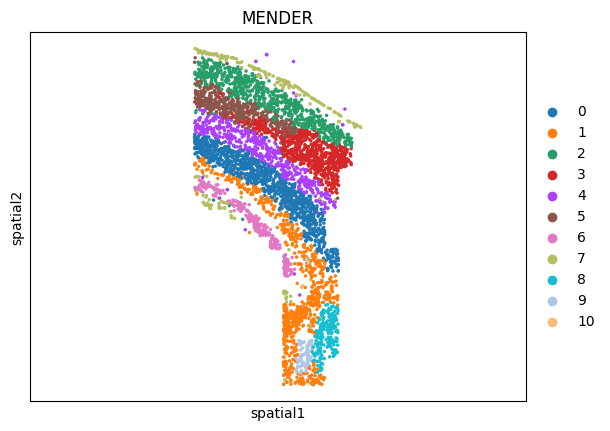

In [10]:
# the plot function has two parameters
# obs: the observation to plot
# gt_obs: the ground truth observation to compute NMI and ARI, can be set to None if not available
msm.output_cluster(obs='MENDER')
print('MENDER prediction')

In [11]:
print(f'running time: {time_cost} s')

running time: 9.998725652694702 s


In [12]:
MENDER.utils.compute_NMI(msm.adata_MENDER,gt_obs,'MENDER')

0.7427551761458686

In [13]:
msm.adata_MENDER.write_h5ad('dump/osmFISH.h5ad')

